In [1]:
from pathlib import Path
import glob 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

dataset = 'kitti'

In [2]:
result_total = pd.DataFrame()
columns = ['EvalType', 'APType', 'Easy', 'Moderate', 'Hard']
plot_dir = Path(f"../artifacts/plots/{dataset}")
plot_dir.mkdir(exist_ok=True,parents=True)

In [3]:
import pandas as pd
import re

# Function to extract AP40 results from the text
def extract_ap40_results(file_path):
    # # Open and read the text file
    with open(file_path, 'r') as file:
        data = file.read()
    # data = file_path
    # Regex pattern to match the AP40 data for Pedestrian, Cyclist, and Car
    pattern = r"(\w+)\sAP40@([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+):\n\s*bbox AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)\n\s*bev\s*AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)\n\s*3d\s*AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)"
    
    # Find all matching AP40 results
    matches = re.findall(pattern, data)

    # Prepare the data for the dataframe
    results = []
    for match in matches:
        class_name = match[0]
        iou1 = float(match[1])
        iou2 = float(match[2])
        iou3 = float(match[3])
        bbox_values = [float(match[4]), float(match[5]), float(match[6])]
        bev_values = [float(match[7]), float(match[8]), float(match[9])]
        threed_values = [float(match[10]), float(match[11]), float(match[12])]
        
        results.append([class_name, iou1, iou2, iou3] + bbox_values + bev_values + threed_values)

    # Define column names
    columns = ['Class', 'IoU-Easy', 'IoU-Moderate', 'IoU-Hard', '2D-Easy', '2D-Moderate', '2D-Hard', 
               'BEV-Easy', 'BEV-Moderate', 'BEV-Hard', '3D-Easy', '3D-Moderate', '3D-Hard']

    # Create a DataFrame
    df = pd.DataFrame(results, columns=columns)
    return df

In [4]:
columns = ['EvalType', 'APType', 'Easy', 'Moderate', 'Hard']
list_of_trip = [
    '0000', 
    '0001', 
    '0002', 
    '0003', 
    '0004', 
    '0005', 
    '0006', 
    '0007', 
    '0008', 
    '0009',
    ]

In [5]:
result_total = pd.DataFrame()
destRootdir = Path('/home/hasan/workspace/datasets/multimodal/tracking/newTracking/')
for tripDir in list(destRootdir.iterdir()):
    print(tripDir)
    tripID = tripDir.stem
    # if tripID != '0000':
    #     continue
    result_files = glob.glob(str(tripDir)+'/kitti_results_*.txt')

    
    for file_dir in result_files:
        file_dir = Path(file_dir)
        file_name = file_dir.stem
        Delay_Camera = int(file_name.split("_")[2])
        delay_lidar = int(file_name.split("_")[3])

        df = extract_ap40_results(file_dir)
        filter_ped = (df['Class'] == 'Pedestrian') & (df['IoU-Easy'] == 0.5) & (df['IoU-Moderate'] == 0.5) & (df['IoU-Hard'] == 0.5)
        filter_cyc = (df['Class'] == 'Cyclist') & (df['IoU-Easy'] == 0.5) & (df['IoU-Moderate'] == 0.5) & (df['IoU-Hard'] == 0.5)
        filter_car = (df['Class'] == 'Car') & (df['IoU-Easy'] == 0.7) & (df['IoU-Moderate'] == 0.7) & (df['IoU-Hard'] == 0.7)
        final_filter = filter_ped | filter_cyc | filter_car
        result_ind = df[final_filter]
        result_ind = result_ind.reset_index(drop=True)
        # result_ind = pd.DataFrame(result_ind, columns=columns)
        result_ind['Delay_Camera'] = Delay_Camera
        result_ind['Delay_Lidar'] = delay_lidar
        result_ind['TripID'] = tripID
        result_total = pd.concat([result_total, result_ind], axis=0)
        print(result_total.shape)

result_total = result_total.sort_values(by=['Delay_Camera', 'Delay_Lidar'])
# result_total[['Easy', 'Moderate', 'Hard']] = result_total[['Easy', 'Moderate', 'Hard']].astype(float)
result_total[['Delay_Camera','Delay_Lidar']] = result_total[['Delay_Camera','Delay_Lidar']].astype(int)
# result_dir = Path("../artifacts/results/results_total.csv")
# result_dir.parent.mkdir(exist_ok=True,parents=True)
# result_total.to_csv(result_dir, header=True)
result_total.reset_index(drop=True, inplace=True)

/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0006
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0015
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0013
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0003
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0011
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0012
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0008
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0007
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0016
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0004
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0010
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0009
/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0000
(3, 16)
(6, 16)
(9, 16)
(12, 16)
(15, 16)
(18, 16)
(21, 16)
(24, 16)
(27, 16)
(30, 16)
(33, 16)
(36, 16)
(39, 16)
(4

In [6]:
filter_cam = result_total['Delay_Camera'] == 0
filter_lid = result_total['Delay_Lidar'] == 0
result_filter = result_total[filter_cam & filter_lid]
comb_to_drop = result_filter[['3D-Easy', '3D-Moderate', '3D-Hard']].min(axis=1) == 0.0
comb_to_drop = result_filter[['3D-Easy', '3D-Moderate', '3D-Hard']].mean(axis=1) < 50.00
pairs_to_ignore = result_filter[comb_to_drop][['Class', 'TripID']].values
pairs_to_ignore

array([['Pedestrian', '0000']], dtype=object)

In [7]:
# filter_cam = result_total['Delay_Camera'] == 0
# filter_lid = result_total['Delay_Lidar'] == 0
# result_filter = result_total[filter_cam & filter_lid]
# comb_to_drop = result_filter[['3D-Easy', '3D-Moderate', '3D-Hard']].min(axis=1) == 50.00
# pairs_to_ignore = result_filter[comb_to_drop][['Class', 'TripID']].values
# pairs_to_ignore


In [8]:
result_total_backup = result_total.copy()

In [9]:
for class_name, trip_id in pairs_to_ignore:
    result_total = result_total[~((result_total['Class'] == class_name) & (result_total['TripID'] == trip_id))]

In [10]:
result_total

,Class,IoU-Easy,IoU-Moderate,IoU-Hard,2D-Easy,2D-Moderate,2D-Hard,BEV-Easy,BEV-Moderate,BEV-Hard,3D-Easy,3D-Moderate,3D-Hard,Delay_Camera,Delay_Lidar,TripID
1,Cyclist,0.5,0.5,0.5,100.0000,100.0000,100.0000,99.8043,99.7892,99.7892,99.8043,99.7892,99.7892,0,0,0000
2,Car,0.7,0.7,0.7,99.8462,99.8732,95.6004,98.2508,95.6537,85.8423,97.9967,95.3647,79.4320,0,0,0000
4,Cyclist,0.5,0.5,0.5,99.8031,99.7878,99.7878,89.2306,89.2163,89.2163,85.8577,85.8435,85.8435,0,1,0000
5,Car,0.7,0.7,0.7,52.3612,51.9056,52.8482,16.1396,11.2725,6.4320,4.0321,2.7985,1.4845,0,1,0000
7,Cyclist,0.5,0.5,0.5,60.4789,60.4674,60.4674,46.2382,46.2382,46.2382,31.2171,31.2171,31.2171,0,2,0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,Car,0.7,0.7,0.7,2.0074,1.2040,1.6574,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5,3,0000
103,Cyclist,0.5,0.5,0.5,21.2968,21.2968,21.2968,4.7787,4.7787,4.7787,2.1057,2.1057,2.1057,5,4,0000
104,Car,0.7,0.7,0.7,0.0000,0.1205,0.9722,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5,4,0000
106,Cyclist,0.5,0.5,0.5,13.2889,13.2889,13.2889,2.4378,2.4378,2.4378,0.2703,0.2703,0.2703,5,5,0000


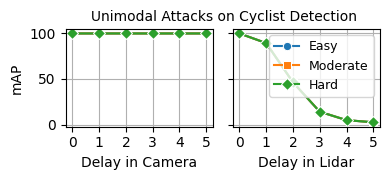

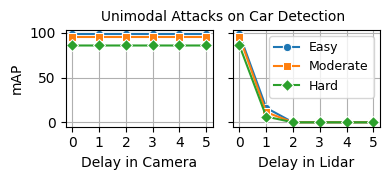

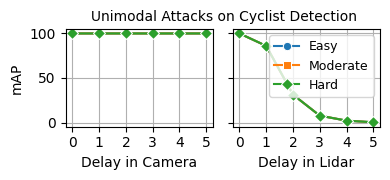

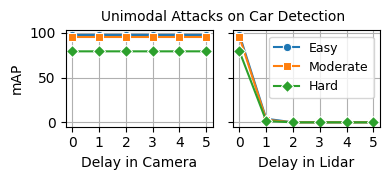

In [11]:
markers = ['o', 's', 'D', '^', 'v', 'x', 'P', '*']

import matplotlib.colors as mcolors
result_total = result_total[result_total['TripID'].isin(list_of_trip)] # '0001', '0002'])] #, '0003' ])] #, '0003', '0004', '0005', '0006', '0007', '0008', '0009'])
result_total = result_total.reset_index(drop=True)

for eval_type in ['BEV', '3D']:

    for cls_idx, class_name in enumerate(result_total['Class'].unique()):

        fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)
        for diff_idx, ap_type in enumerate(['Easy', 'Moderate', 'Hard']):

            result_total_class = result_total[result_total['Class'] == class_name]
            metric = eval_type+"-"+ap_type
            result_total_class = result_total_class[[metric, 'Delay_Camera', 'Delay_Lidar', 'TripID']]
            result_total_class = result_total_class.reset_index(drop=True)


            # Plot Image Delay
            data = result_total_class[result_total_class['Delay_Lidar'] == 0]
            data = data[data['Delay_Camera'] <= 5]
            sns.lineplot(data=data, x='Delay_Camera', y=metric, marker = markers[diff_idx] , ax = axes[0],) #palette="tab10", 
            axes[0].set_xlabel('Delay in Camera')
            axes[0].set_ylabel('mAP')
            # axes[0].set_title(f"{class_name} {eval_type} mAP")
            # axes[0].set_xlabel('Delay (ms)')
            # axes[0].set_ylabel('mAP')
            # axes[0].set_ylim(0, 1)
            axes[0].set_xticks([0, 1, 2, 3, 4, 5])
            # axes[0].set_xlim(0, 5)
            # axes[0].legend(title='AP Type', loc='upper right')
            axes[0].grid(True) 

            # Plot Lidar Delay
            data = result_total_class[result_total_class['Delay_Camera'] == 0]
            data = data[data['Delay_Lidar'] <= 5]
            sns.lineplot(data=data, x='Delay_Lidar', y=metric, marker = markers[diff_idx] , ax = axes[1], label=ap_type) #palette="tab10",
            # axes[1].set_title(f"{class_name} {eval_type} mAP")
            axes[1].set_xlabel('Delay in Lidar')
            axes[1].set_ylabel('mAP')
            # axes[1].set_ylim(0, 1)
            axes[1].set_xticks([0, 1, 2, 3, 4, 5])
            # axes[1].set_xlim(0, 5)
            axes[1].legend(loc='upper right', fontsize='9') #title='Difficulty', 
            axes[1].grid(True) 
        fig.suptitle(f"             Unimodal Attacks on {class_name} Detection", fontsize=10, y=0.875)
        # fig.suptitle("My Title", y=0.95)

        fig.tight_layout()
        # fig_dir = plot_dir / f"attack_impact_line_{dataset}_{eval_type}_{class_name}"
        # fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
        # fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
        plt.show()

In [12]:
result_total['mAP'] = result_total[['3D-Easy', '3D-Moderate', '3D-Hard']].mean(axis=1)
result_total['mAP']

0     99.794233
1     90.931133
2     85.848233
3      2.771700
4     31.217100
        ...    
67     0.000000
68     2.105700
69     0.000000
70     0.270300
71     0.000000
Name: mAP, Length: 72, dtype: float64

In [13]:
result_total

,Class,IoU-Easy,IoU-Moderate,IoU-Hard,2D-Easy,2D-Moderate,2D-Hard,BEV-Easy,BEV-Moderate,BEV-Hard,3D-Easy,3D-Moderate,3D-Hard,Delay_Camera,Delay_Lidar,TripID,mAP
0,Cyclist,0.5,0.5,0.5,100.0000,100.0000,100.0000,99.8043,99.7892,99.7892,99.8043,99.7892,99.7892,0,0,0000,99.794233
1,Car,0.7,0.7,0.7,99.8462,99.8732,95.6004,98.2508,95.6537,85.8423,97.9967,95.3647,79.4320,0,0,0000,90.931133
2,Cyclist,0.5,0.5,0.5,99.8031,99.7878,99.7878,89.2306,89.2163,89.2163,85.8577,85.8435,85.8435,0,1,0000,85.848233
3,Car,0.7,0.7,0.7,52.3612,51.9056,52.8482,16.1396,11.2725,6.4320,4.0321,2.7985,1.4845,0,1,0000,2.771700
4,Cyclist,0.5,0.5,0.5,60.4789,60.4674,60.4674,46.2382,46.2382,46.2382,31.2171,31.2171,31.2171,0,2,0000,31.217100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Car,0.7,0.7,0.7,2.0074,1.2040,1.6574,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5,3,0000,0.000000
68,Cyclist,0.5,0.5,0.5,21.2968,21.2968,21.2968,4.7787,4.7787,4.7787,2.1057,2.1057,2.1057,5,4,0000,2.105700
69,Car,0.7,0.7,0.7,0.0000,0.1205,0.9722,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5,4,0000,0.000000
70,Cyclist,0.5,0.5,0.5,13.2889,13.2889,13.2889,2.4378,2.4378,2.4378,0.2703,0.2703,0.2703,5,5,0000,0.270300


metric: mAP
metric: mAP


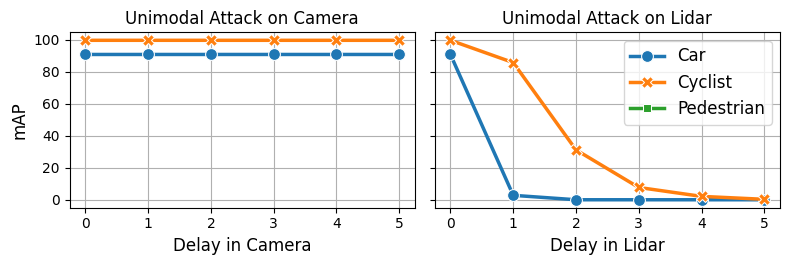

In [14]:
metric = 'mAP'
fig, axes = plt.subplots(1, 2, figsize=(8, 2.75), sharex=True, sharey=True)
for ax, (tar_mod, safe_mod) in zip(axes, [['Delay_Camera', 'Delay_Lidar'], ['Delay_Lidar', 'Delay_Camera']]):
    print(f"metric: {metric}")
    
    df = result_total[(result_total[safe_mod] == 0) & (result_total[tar_mod] <= 5)]
    # legend_order = df[(df['Delay_Lidar'] == 0) & (df['Delay_Camera'] == 0)].sort_values(['mAP'], ascending=False)['Class'].values
    legend_order = ['Car', 'Cyclist', 'Pedestrian']
    sns.lineplot(
        data=df,
        x=tar_mod,
        y=metric,
        hue='Class',
        style='Class',
        hue_order=legend_order,      # <- Custom order here
        style_order=legend_order,    # <- Keep markers/styles consistent
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8.5,
        ax=ax,
        errorbar=None
    )

    # sns.lineplot(
    #     data=df,
    #     x=tar_mod,
    #     y=metric,
    #     hue='Class',
    #     style='TripID',
    #     # hue_order=legend_order,      # <- Custom order here
    #     # style_order=legend_order,    # <- Keep markers/styles consistent
    #     markers=True,
    #     dashes=False,
    #     linewidth=2.5,
    #     markersize=8.5,
    #     ax=ax
    # )

    ax.set_xlabel(tar_mod.replace("_", " in "), fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("mAP", fontsize=12)
        ax.legend().set_visible(False)
    else:
        ax.legend(bbox_to_anchor=(1, 1.0), fontsize=12)
    ax.grid(True)
    target_mod = tar_mod.split("_")[1].capitalize()
    ax.set_title(f"Unimodal Attack on {target_mod}", fontsize=12)
    # ax.set_ylim(0, 100)        # 
    ax.set_xticks([0,1,2,3,4,5])
    # print("df", df)
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_line_{dataset}_{metric}_hue_classes"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()

In [15]:
df

,Class,IoU-Easy,IoU-Moderate,IoU-Hard,2D-Easy,2D-Moderate,2D-Hard,BEV-Easy,BEV-Moderate,BEV-Hard,3D-Easy,3D-Moderate,3D-Hard,Delay_Camera,Delay_Lidar,TripID,mAP
0,Cyclist,0.5,0.5,0.5,100.0000,100.0000,100.0000,99.8043,99.7892,99.7892,99.8043,99.7892,99.7892,0,0,0000,99.794233
1,Car,0.7,0.7,0.7,99.8462,99.8732,95.6004,98.2508,95.6537,85.8423,97.9967,95.3647,79.4320,0,0,0000,90.931133
2,Cyclist,0.5,0.5,0.5,99.8031,99.7878,99.7878,89.2306,89.2163,89.2163,85.8577,85.8435,85.8435,0,1,0000,85.848233
3,Car,0.7,0.7,0.7,52.3612,51.9056,52.8482,16.1396,11.2725,6.4320,4.0321,2.7985,1.4845,0,1,0000,2.771700
4,Cyclist,0.5,0.5,0.5,60.4789,60.4674,60.4674,46.2382,46.2382,46.2382,31.2171,31.2171,31.2171,0,2,0000,31.217100
5,Car,0.7,0.7,0.7,14.0614,12.9213,9.9806,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,2,0000,0.000000
6,Cyclist,0.5,0.5,0.5,35.6622,35.6622,35.6622,14.0141,14.0141,14.0141,7.6906,7.6906,7.6906,0,3,0000,7.690600
7,Car,0.7,0.7,0.7,2.0074,1.2040,1.6546,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,3,0000,0.000000
8,Cyclist,0.5,0.5,0.5,21.3078,21.3078,21.3078,4.7787,4.7787,4.7787,2.1057,2.1057,2.1057,0,4,0000,2.105700
9,Car,0.7,0.7,0.7,0.0000,0.1205,0.9722,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,4,0000,0.000000


In [16]:
# result_total = result_total[result_total['TripID'].isin(['0000'])] #, '0001', '0002'])] #, '0003', '0004', '0005', '0006', '0007', '0008', '0009'])
# result_total = result_total.reset_index(drop=True)
# result_total = result_total[(result_total['Delay_Camera'] <= 5) & (result_total['Delay_Lidar'] <= 5)]


# for cls_idx, class_name in enumerate(result_total['Class'].unique()):
#     fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)
#     result_total_per_Class = result_total[result_total['Class'] == class_name]

#     for eval_idx, eval_type in enumerate(['3D']):
            
#         metric = [eval_type+"-"+ap_type for ap_type in ['Easy', 'Moderate', 'Hard']]
#         result_total_class = result_total_per_Class[metric + ['Delay_Camera', 'Delay_Lidar', 'TripID']]
#         result_total_class = result_total_class.reset_index(drop=True)
#         result_total_class = result_total_class.melt(id_vars=['Delay_Camera', 'Delay_Lidar', 'TripID'], value_vars=metric, var_name='APType', value_name='mAP')



#         df_pivot = result_total_class.pivot_table(columns='Delay_Camera', index='Delay_Lidar', values='mAP', aggfunc='mean').iloc[0:6, 0:6]
#         print("class_name \n", result_total_class[['Delay_Camera', 'Delay_Lidar', 'mAP']])

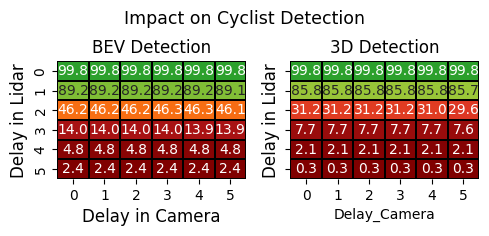

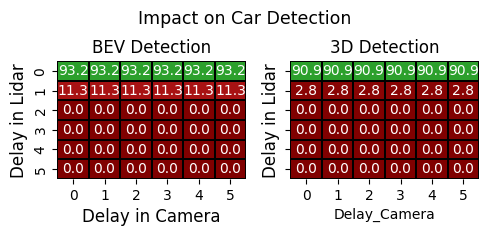

In [17]:
import matplotlib.colors as mcolors
result_total = result_total[result_total['TripID'].isin(list_of_trip)] #, '0001', '0002'])] #, '0003', '0004', '0005', '0006', '0007', '0008', '0009'])
result_total = result_total.reset_index(drop=True)
result_total = result_total[(result_total['Delay_Camera'] <= 5) & (result_total['Delay_Lidar'] <= 5)]


for cls_idx, class_name in enumerate(result_total['Class'].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)
    result_total_per_Class = result_total[result_total['Class'] == class_name]

    for eval_idx, eval_type in enumerate(['BEV', '3D']):
            
        metric = [eval_type+"-"+ap_type for ap_type in ['Easy', 'Moderate', 'Hard']]
        result_total_class = result_total_per_Class[metric + ['Delay_Camera', 'Delay_Lidar', 'TripID']]
        result_total_class = result_total_class.reset_index(drop=True)
        result_total_class = result_total_class.melt(id_vars=['Delay_Camera', 'Delay_Lidar', 'TripID'], value_vars=metric, var_name='APType', value_name='mAP')

        df_pivot = result_total_class.pivot_table(columns='Delay_Camera', index='Delay_Lidar', values='mAP', aggfunc='mean').iloc[0:6, 0:6]

        # print(eval_type, "\n\n" ,df_pivot)

        # Custom colormap with multiple color transitions
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
        cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

        # vmin = result_total_class[metric].min()
        # vmax = result_total_class[metric].max()

        sns.heatmap(df_pivot, fmt='0.1f', annot=True, linewidths=0.10, linecolor='black',  cmap=cmap,  ax=axes[eval_idx], cbar=False,) # vmin=vmin, vmax=vmax,) #vmin=vmin, vmax=vmax,
        # axes[diff_idx].set_xticklabels(axes[diff_idx].get_xticklabels(), rotation=0)
        # axes[diff_idx].set_yticklabels(axes[diff_idx].get_yticklabels(), rotation=0)
        axes[eval_idx].set_title(f"{eval_type} Detection", fontsize=12)
        if eval_idx == 0:
            axes[eval_idx].set_xlabel("Delay in Camera", fontsize=12)
        else:
            axes[eval_idx].set_ylabel("")

        axes[eval_idx].set_ylabel("Delay in Lidar", fontsize=12)

    fig.suptitle(f"Impact on {class_name} Detection",  y=0.925, fontsize=12.5)
    fig.tight_layout()

    # fig_dir = plot_dir / f"attack_impact_avg_grid_{dataset}_{class_name}"
    # fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
    # fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
    plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

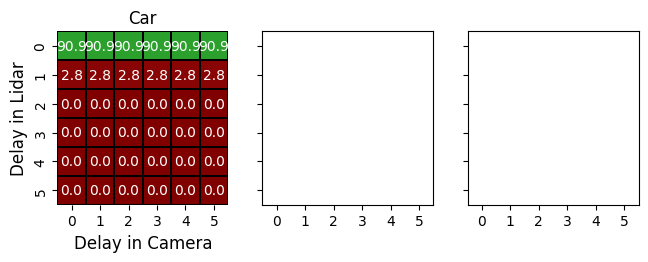

In [18]:
import matplotlib.colors as mcolors
result_total = result_total[result_total['TripID'].isin(list_of_trip)] #, '0001', '0002'])] #, '0003', '0004', '0005', '0006', '0007', '0008', '0009'])
result_total = result_total.reset_index(drop=True)
result_total = result_total[(result_total['Delay_Camera'] <= 5) & (result_total['Delay_Lidar'] <= 5)]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.25), sharex=True, sharey=True)
for cls_idx, class_name in enumerate(['Car', 'Pedestrian', 'Cyclist']):
    result_total_per_Class = result_total[result_total['Class'] == class_name]

    for eval_idx, eval_type in enumerate(['3D']):
            
        metric = [eval_type+"-"+ap_type for ap_type in ['Easy', 'Moderate', 'Hard']]
        result_total_class = result_total_per_Class[metric + ['Delay_Camera', 'Delay_Lidar', 'TripID']]
        result_total_class = result_total_class.reset_index(drop=True)
        result_total_class = result_total_class.melt(id_vars=['Delay_Camera', 'Delay_Lidar', 'TripID'], value_vars=metric, var_name='APType', value_name='mAP')

        df_pivot = result_total_class.pivot_table(columns='Delay_Camera', index='Delay_Lidar', values='mAP', aggfunc='mean').iloc[0:6, 0:6]

        # print(eval_type, "\n\n" ,df_pivot)

        # Custom colormap with multiple color transitions
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
        cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

        # vmin = result_total_class[metric].min()
        # vmax = result_total_class[metric].max()

        sns.heatmap(df_pivot, fmt='0.1f', annot=True, linewidths=0.10, linecolor='black', cmap=cmap,  ax=axes[cls_idx], cbar=False,) # vmin=vmin, vmax=vmax,) #vmin=vmin, vmax=vmax,
        # axes[diff_idx].set_xticklabels(axes[diff_idx].get_xticklabels(), rotation=0)
        # axes[diff_idx].set_yticklabels(axes[diff_idx].get_yticklabels(), rotation=0)
        axes[cls_idx].set_title(f"{class_name}", fontsize=12)
        if cls_idx == 0:
            axes[cls_idx].set_ylabel("Delay in Lidar", fontsize=12)
        else:
            axes[cls_idx].set_ylabel("")
            
        axes[cls_idx].set_xlabel("Delay in Camera", fontsize=12)
    

# fig.suptitle(f"Impact on {class_name} Detection",  y=0.925, fontsize=12.5)
fig.tight_layout()

fig_dir = plot_dir / f"attack_impact_avg_grid_{eval_type}_{dataset}_three_class"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()

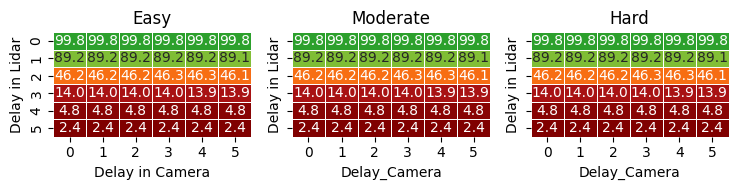

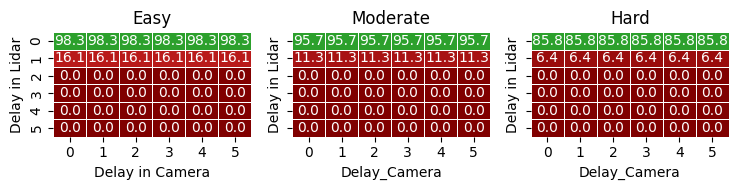

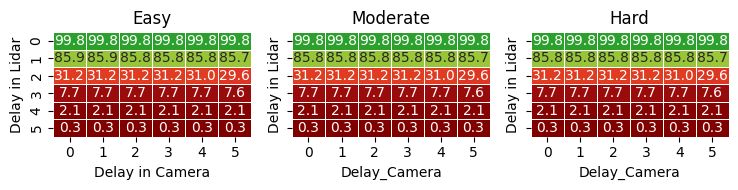

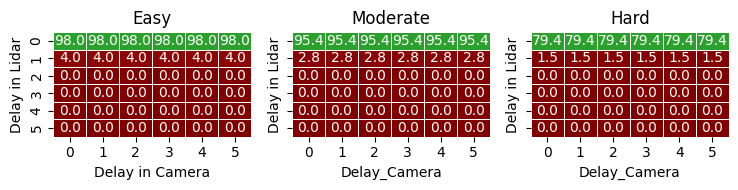

In [19]:
import matplotlib.colors as mcolors
result_total = result_total[result_total['TripID'].isin(list_of_trip)] #, '0001', '0002'])] #, '0003', '0004', '0005', '0006', '0007', '0008', '0009'])
result_total = result_total.reset_index(drop=True)

for eval_type in ['BEV', '3D']:

    for cls_idx, class_name in enumerate(result_total['Class'].unique()):
        fig, axes = plt.subplots(1, 3, figsize=(7.5, 2), sharex=True, sharey=True)
        # fig.suptitle(f"Impact of Delay on {class_name} {eval_type} mAP", fontsize=12)
        # fig.subplots_adjust(hspace=0.4, wspace=0.4)
        # fig.patch.set_facecolor('white')
        # fig.patch.set_alpha(0.8)
        # fig.patch.set_edgecolor('black')

        for diff_idx, ap_type in enumerate(['Easy', 'Moderate', 'Hard']):
            result_total_class = result_total[result_total['Class'] == class_name]
            metric = eval_type+"-"+ap_type
            result_total_class = result_total_class[[metric, 'Delay_Camera', 'Delay_Lidar', 'TripID']]
            result_total_class = result_total_class.reset_index(drop=True)

            df_pivot = result_total_class.pivot_table(columns='Delay_Camera', index='Delay_Lidar', values=metric, aggfunc='mean')


            # Custom colormap with multiple color transitions
            colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
            cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

            vmin = result_total_class[metric].min()
            vmax = result_total_class[metric].max()

            sns.heatmap(df_pivot.iloc[0:6, 0:6], fmt='0.1f', annot=True, cmap=cmap, linewidths=0.5,  ax=axes[diff_idx], cbar=False, vmin=vmin, vmax=vmax,) #vmin=vmin, vmax=vmax,
            # axes[diff_idx].set_xticklabels(axes[diff_idx].get_xticklabels(), rotation=0)
            # axes[diff_idx].set_yticklabels(axes[diff_idx].get_yticklabels(), rotation=0)
            axes[diff_idx].set_title(f"{ap_type}")
            if diff_idx == 0:
                axes[diff_idx].set_xlabel("Delay in Camera")
            else:
                axes[diff_idx].set_ylabel("")
            axes[diff_idx].set_ylabel("Delay in Lidar")
        fig.tight_layout()
        # fig_dir = plot_dir / f"attack_impact_grid_{dataset}_{eval_type}_{class_name}"
        # fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
        # fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
        plt.show()

In [20]:
break-here

SyntaxError: invalid syntax (1867221069.py, line 1)

In [ ]:
# list((tripDir/'testing'/'image_2').iterdir())

In [ ]:
# import os

# def summarize_final_folder_details(root_folder):
#     final_folder_summary = {}

#     for foldername, subfolders, filenames in os.walk(root_folder):
#         if not subfolders:  # Check if the folder has no subfolders
#             num_files = len(filenames)
#             final_folder_summary[foldername] = num_files

#     return final_folder_summary

# # def print_summary(summary):
# #     for folder, num_files in summary.items():
# #         print(f"Folder: {folder}")
# #         print(f"Number of files: {num_files}")
# #         print("-" * 20)

# summary = summarize_final_folder_details('/home/hasan/workspace/datasets/multimodal/tracking/newTracking/')
# summary

In [ ]:
result_total = pd.DataFrame()
columns = ['EvalType', 'APType', 'Easy', 'Moderate', 'Hard']

destRootdir = Path('/home/hasan/workspace/datasets/multimodal/tracking/newTracking/')
for tripDir in list(destRootdir.iterdir()):
    print(tripDir)
    tripID = tripDir.stem
    # if tripID != '0000':
    #     continue
    result_files = glob.glob(str(tripDir)+'/kitti_results_*.txt')

    
    for file_dir in result_files:
        file_dir = Path(file_dir)
        file_name = file_dir.stem
        Delay_Camera = int(file_name.split("_")[2])
        delay_lidar = int(file_name.split("_")[3])
        # print(Delay_Camera, delay_lidar)
        result_ind = []
        f = open(file_dir, "r")
        data = f.read()
        data = data.split('\n')
        # for line_no, line in enumerate(data[-11:-7]):
        start = False
        for line_no, line in enumerate(data):
            # print(line)
            line = line.replace(":", " ")
            line = line.replace(",", " ")
            line = line.replace("@", " ")
            # print(line)

            words = line.split()
            # if line == 'Overall AP40 easy  moderate  hard' :
            if len(words) > 2:
                if words[0] == 'Overall' and words[1] == 'AP40': # easy  moderate  hard' :
                    start = True
                    continue
                if start and words[0] in ['bbox', 'bev', '3d', 'aos']:
                    result_ind.append(words)
                elif start:
                    print(words)

            # if line_no == 0:
            #     print(words)
            #     if words[0] != 'Overall': # != ['Overall', 'AP40', 'easy', 'moderate', 'hard']:
            #         print("Skipping as there is a mismatch in the header")
            #         print(words)
            #         break
            # else:
            #     print(words)
            #     result_ind.append(words)
        result_ind = pd.DataFrame(result_ind, columns=columns)
        result_ind['Delay_Camera'] = Delay_Camera
        result_ind['Delay_Lidar'] = delay_lidar
        result_ind['TripID'] = tripID
        result_total = pd.concat([result_total, result_ind], axis=0)
        print(result_total.shape)

result_total = result_total.sort_values(by=['Delay_Camera', 'Delay_Lidar'])
result_total[['Easy', 'Moderate', 'Hard']] = result_total[['Easy', 'Moderate', 'Hard']].astype(float)
result_total[['Delay_Camera','Delay_Lidar']] = result_total[['Delay_Camera','Delay_Lidar']].astype(int)
result_dir = Path("../artifacts/results/results_total.csv")
result_dir.parent.mkdir(exist_ok=True,parents=True)
result_total.to_csv(result_dir, header=True)

/home/hasan/workspace/datasets/multimodal/tracking/newTracking/0009
['10/15', '08', '28', '31', '-', 'mmengine', '-', 'INFO', '-', 'Epoch(test)', '[793/793]', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_easy_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_easy_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_easy_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_moderate_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_moderate_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_moderate_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_hard_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_hard_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_hard_strict', '0.0000', 'Kitti', 'metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_easy_loose

In [ ]:
result_total = result_total[result_total['TripID'].isin(['0000', '0001', '0002'])]

In [ ]:
# result_total = result_total[result_total['Easy'] > 50]

(0.0, 100.0)

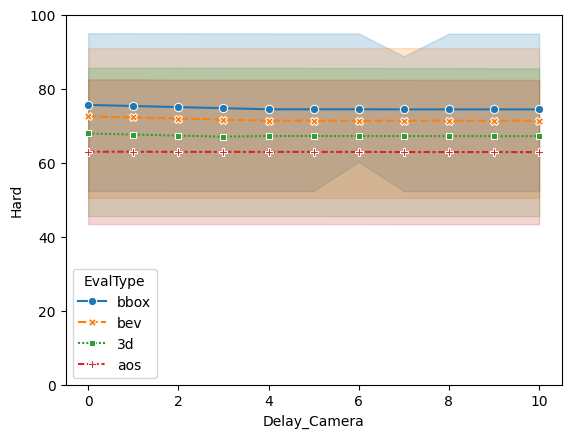

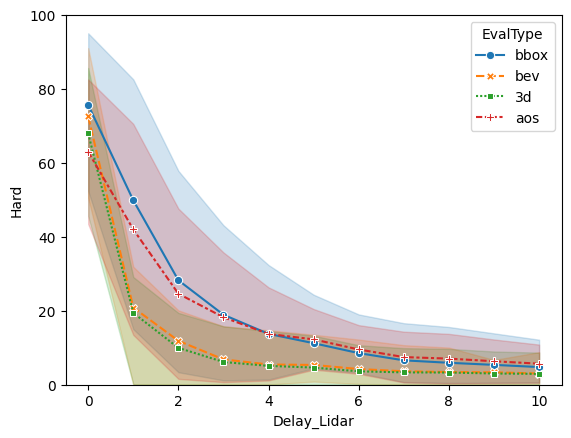

In [ ]:
plt.figure()
sns.lineplot(result_total[result_total['Delay_Lidar'] == 0], x = "Delay_Camera", y = "Hard", hue = 'EvalType', style = 'EvalType', markers=True)
plt.ylim(0,100)

plt.figure()
sns.lineplot(result_total[result_total['Delay_Camera'] == 0], x = "Delay_Lidar", y = "Hard", hue = 'EvalType', style = 'EvalType', markers=True)
plt.ylim(0,100)

(0.0, 100.0)

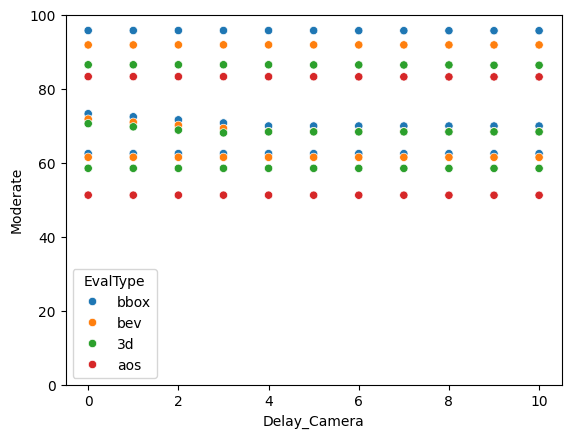

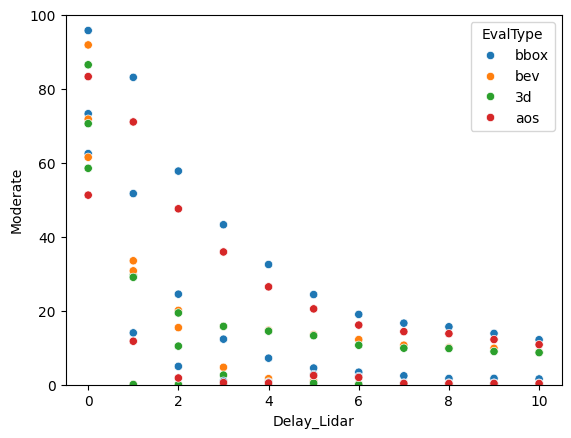

In [ ]:
plt.figure()
# sns.boxplot(result_total[result_total['Delay_Lidar'] == 0], x = "Delay_Camera", y = "Hard", hue = 'EvalType') #, style = 'EvalType', markers=True)
sns.scatterplot(result_total[result_total['Delay_Lidar'] == 0], x = "Delay_Camera", y = "Moderate", hue = 'EvalType') #, style = 'EvalType', markers=True)
plt.ylim(0,100)

plt.figure()
# sns.boxplot(result_total[result_total['Delay_Camera'] == 0], x = "Delay_Lidar", y = "Hard", hue = 'EvalType') #, style = 'EvalType', markers=True)
sns.scatterplot(result_total[result_total['Delay_Camera'] == 0], x = "Delay_Lidar", y = "Moderate", hue = 'EvalType') #, style = 'EvalType', markers=True)
plt.ylim(0,100)

In [ ]:
import pandas as pd

# # Assuming `df` is your initial DataFrame
# df = pd.DataFrame({
#     'EvalType': ['bbox', 'bev', '3d', 'aos', 'bbox', 'aos', 'bbox', 'bev', '3d', 'aos'],
#     'APType': ['AP40'] * 10,
#     'Easy': [33.3235, 32.1069, 30.1990, 33.3000, 53.7130, 54.5600, 32.3322, 32.3246, 31.6998, 32.2100],
#     'Moderate': [32.1051, 30.0232, 23.1679, 32.0700, 50.5201, 51.2300, 36.9825, 35.9631, 33.5218, 36.3800],
#     'Hard': [32.0878, 29.9884, 23.0442, 32.0600, 52.0183, 43.4000, 53.3238, 52.2773, 48.8803, 43.5200],
#     'Delay_Camera': [0, 0, 0, 0, 0, 10, 10, 10, 10, 10],
#     'Delay_Lidar': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     'TripID': ['0008', '0008', '0008', '0008', '0007', '0001', '0009', '0009', '0009', '0009']
# })

# Reshape the DataFrame
df_melted = result_total.melt(
    id_vars=['EvalType', 'APType', 'Delay_Camera', 'Delay_Lidar', 'TripID'],
    value_vars=['Easy', 'Moderate', 'Hard'],
    var_name='Difficulty',
    value_name='mAP'
)

print(df_melted)


    EvalType APType  Delay_Camera  Delay_Lidar TripID Difficulty      mAP
0       bbox   AP40             0            0   0000       Easy  72.4487
1        bev   AP40             0            0   0000       Easy  71.8517
2         3d   AP40             0            0   0000       Easy  70.7253
3       bbox   AP40             0            0   0001       Easy  65.0158
4        bev   AP40             0            0   0001       Easy  64.9300
..       ...    ...           ...          ...    ...        ...      ...
913      aos   AP40            10            0   0001       Hard  43.4000
914     bbox   AP40            10            0   0002       Hard  94.9404
915      bev   AP40            10            0   0002       Hard  91.0470
916       3d   AP40            10            0   0002       Hard  85.5567
917      aos   AP40            10            0   0002       Hard  82.4200

[918 rows x 7 columns]


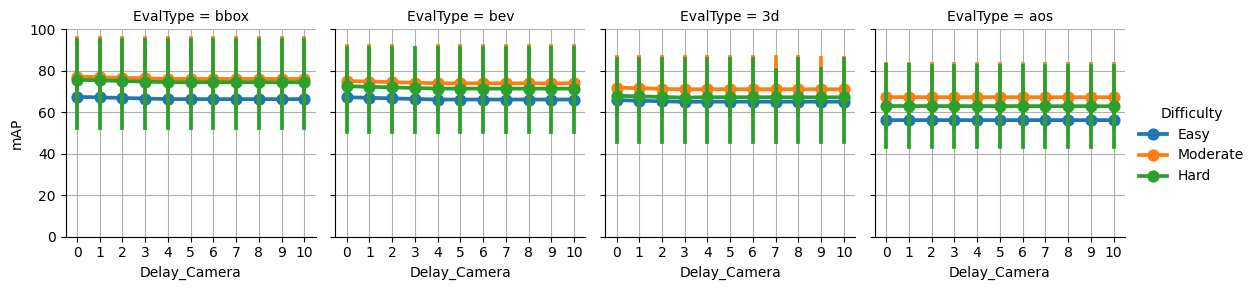

In [ ]:
# Assuming df_melted is already defined
df = df_melted[df_melted['Delay_Lidar'] == 0]

# Create a catplot
ax = sns.catplot(data=df, col='EvalType', x='Delay_Camera', hue='Difficulty', y='mAP', kind='point', aspect=0.95, height=3)

# Set the y-axis limits for all subplots
for axis in ax.axes.flat:
    axis.set_ylim(0, 100)  # Set y-axis limits (0, 1)
    axis.grid(True)       # Enable grid

# Save the plot
fig_dir = plot_dir / "attack_impact_camera_lidar.jpg"
plt.savefig(fig_dir, dpi=350)

# Show the plot
plt.show()


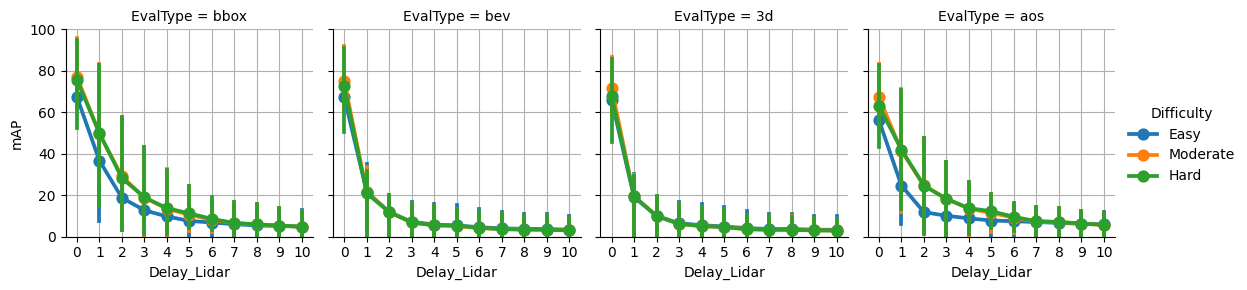

In [ ]:
# Assuming df_melted is already defined
df = df_melted[df_melted['Delay_Camera'] == 0]

# Create a catplot
ax = sns.catplot(data=df, col = 'EvalType', x='Delay_Lidar', hue = 'Difficulty', y = 'mAP', kind='point', aspect=0.95, height=3)

# Set the y-axis limits for all subplots
for axis in ax.axes.flat:
    axis.set_ylim(0, 100)  # Set y-axis limits (0, 1)
    axis.grid(True)       # Enable grid

# Save the plot
fig_dir = plot_dir / "attack_impact_delay_lidar.jpg"
plt.savefig(fig_dir, dpi=350)

# Show the plot
plt.show()


In [ ]:
filter_1 = df_melted['Difficulty'] == 'Easy'
filter_2 = df_melted['EvalType'] == '3d'
df_filtered = df_melted.where(filter_1 & filter_2).dropna()

In [ ]:
df_pivot = df_filtered.pivot(columns='Delay_Camera', index='Delay_Lidar', values='mAP')
df_pivot


ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_pivot.iloc[0:6, 0:6], fmt='0.2f', annot=True, cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=100)
# Save the plot
fig_dir = plot_dir / "attack_impact_grid.jpg"
plt.savefig(fig_dir, dpi=350)
plt.show()

In [ ]:
import matplotlib.colors as mcolors

# Custom colormap with multiple color transitions
colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

vmin = df_melted['mAP'].min()
vmax = df_melted['mAP'].max()

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(df_pivot.iloc[0:6, 0:6], fmt='0.2f', annot=True, cmap=cmap, linewidths=0.5,  vmin=vmin, vmax=vmax, ax=ax)

ax.set_title(f"Attack Impact on mAP")
ax.set_xlabel("Delay in Camera")
ax.set_ylabel("Delay in Lidar")

fig.tight_layout()
fig_dir = plot_dir / f"attack_impact_grid_mAP.jpg"
fig.savefig(fig_dir, dpi=350)
plt.show()


In [ ]:
data = """
01/15 19:07:39 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.20 (default, Oct  3 2024, 15:24:27) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1600495643
    GPU 0: NVIDIA RTX6000-Ada-24Q
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 10.1, V10.1.24
    GCC: gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0
    PyTorch: 1.12.1
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201402
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.6.0 (Git Hash 52b5f107dd9cf10910aaa19cb47f3abf9b349815)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.6
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_37,code=compute_37
  - CuDNN 8.3.2  (built against CUDA 11.5)
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CUDA_VERSION=11.6, CUDNN_VERSION=8.3.2, CXX_COMPILER=/opt/rh/devtoolset-9/root/usr/bin/c++, CXX_FLAGS= -fabi-version=11 -Wno-deprecated -fvisibility-inlines-hidden -DUSE_PTHREADPOOL -fopenmp -DNDEBUG -DUSE_KINETO -DUSE_FBGEMM -DUSE_QNNPACK -DUSE_PYTORCH_QNNPACK -DUSE_XNNPACK -DSYMBOLICATE_MOBILE_DEBUG_HANDLE -DEDGE_PROFILER_USE_KINETO -O2 -fPIC -Wno-narrowing -Wall -Wextra -Werror=return-type -Wno-missing-field-initializers -Wno-type-limits -Wno-array-bounds -Wno-unknown-pragmas -Wno-unused-parameter -Wno-unused-function -Wno-unused-result -Wno-unused-local-typedefs -Wno-strict-overflow -Wno-strict-aliasing -Wno-error=deprecated-declarations -Wno-stringop-overflow -Wno-psabi -Wno-error=pedantic -Wno-error=redundant-decls -Wno-error=old-style-cast -fdiagnostics-color=always -faligned-new -Wno-unused-but-set-variable -Wno-maybe-uninitialized -fno-math-errno -fno-trapping-math -Werror=format -Werror=cast-function-type -Wno-stringop-overflow, LAPACK_INFO=mkl, PERF_WITH_AVX=1, PERF_WITH_AVX2=1, PERF_WITH_AVX512=1, TORCH_VERSION=1.12.1, USE_CUDA=ON, USE_CUDNN=ON, USE_EXCEPTION_PTR=1, USE_GFLAGS=OFF, USE_GLOG=OFF, USE_MKL=ON, USE_MKLDNN=OFF, USE_MPI=OFF, USE_NCCL=ON, USE_NNPACK=ON, USE_OPENMP=ON, USE_ROCM=OFF, 

    TorchVision: 0.13.1
    OpenCV: 4.10.0
    MMEngine: 0.10.5

Runtime environment:
    cudnn_benchmark: False
    mp_cfg: {'mp_start_method': 'fork', 'opencv_num_threads': 0}
    dist_cfg: {'backend': 'nccl'}
    seed: 1600495643
    Distributed launcher: none
    Distributed training: False
    GPU number: 1
------------------------------------------------------------

01/15 19:07:40 - mmengine - INFO - Config:
auto_scale_lr = dict(base_batch_size=16, enable=False)
backend_args = None
class_names = [
    'Pedestrian',
    'Cyclist',
    'Car',
]
data_root = 'data/kitti/'
dataset_type = 'KittiDataset'
default_hooks = dict(
    checkpoint=dict(interval=-1, type='CheckpointHook'),
    logger=dict(interval=50, type='LoggerHook'),
    param_scheduler=dict(type='ParamSchedulerHook'),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    timer=dict(type='IterTimerHook'),
    visualization=dict(type='Det3DVisualizationHook'))
default_scope = 'mmdet3d'
env_cfg = dict(
    cudnn_benchmark=False,
    dist_cfg=dict(backend='nccl'),
    mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0))
input_modality = dict(use_camera=True, use_lidar=True)
launcher = 'none'
load_from = 'checkpoints/dv_mvx-fpn_second_secfpn_adamw_2x8_80e_kitti-3d-3class_20210831_060805-83442923.pth'
log_level = 'INFO'
log_processor = dict(by_epoch=True, type='LogProcessor', window_size=50)
lr = 0.003
metainfo = dict(classes=[
    'Pedestrian',
    'Cyclist',
    'Car',
])
modality = dict(use_camera=True, use_lidar=True)
model = dict(
    data_preprocessor=dict(
        bgr_to_rgb=False,
        mean=[
            102.9801,
            115.9465,
            122.7717,
        ],
        pad_size_divisor=32,
        std=[
            1.0,
            1.0,
            1.0,
        ],
        type='Det3DDataPreprocessor',
        voxel=True,
        voxel_layer=dict(
            max_num_points=-1,
            max_voxels=(
                -1,
                -1,
            ),
            point_cloud_range=[
                0,
                -40,
                -3,
                70.4,
                40,
                1,
            ],
            voxel_size=[
                0.05,
                0.05,
                0.1,
            ]),
        voxel_type='dynamic'),
    img_backbone=dict(
        depth=50,
        frozen_stages=1,
        norm_cfg=dict(requires_grad=False, type='BN'),
        norm_eval=True,
        num_stages=4,
        out_indices=(
            0,
            1,
            2,
            3,
        ),
        style='caffe',
        type='mmdet.ResNet'),
    img_neck=dict(
        in_channels=[
            256,
            512,
            1024,
            2048,
        ],
        norm_cfg=dict(requires_grad=False, type='BN'),
        num_outs=5,
        out_channels=256,
        type='mmdet.FPN'),
    pts_backbone=dict(
        in_channels=256,
        layer_nums=[
            5,
            5,
        ],
        layer_strides=[
            1,
            2,
        ],
        out_channels=[
            128,
            256,
        ],
        type='SECOND'),
    pts_bbox_head=dict(
        anchor_generator=dict(
            ranges=[
                [
                    0,
                    -40.0,
                    -0.6,
                    70.4,
                    40.0,
                    -0.6,
                ],
                [
                    0,
                    -40.0,
                    -0.6,
                    70.4,
                    40.0,
                    -0.6,
                ],
                [
                    0,
                    -40.0,
                    -1.78,
                    70.4,
                    40.0,
                    -1.78,
                ],
            ],
            reshape_out=False,
            rotations=[
                0,
                1.57,
            ],
            sizes=[
                [
                    0.8,
                    0.6,
                    1.73,
                ],
                [
                    1.76,
                    0.6,
                    1.73,
                ],
                [
                    3.9,
                    1.6,
                    1.56,
                ],
            ],
            type='Anchor3DRangeGenerator'),
        assign_per_class=True,
        assigner_per_size=True,
        bbox_coder=dict(type='DeltaXYZWLHRBBoxCoder'),
        diff_rad_by_sin=True,
        feat_channels=512,
        in_channels=512,
        loss_bbox=dict(
            beta=0.1111111111111111,
            loss_weight=2.0,
            type='mmdet.SmoothL1Loss'),
        loss_cls=dict(
            alpha=0.25,
            gamma=2.0,
            loss_weight=1.0,
            type='mmdet.FocalLoss',
            use_sigmoid=True),
        loss_dir=dict(
            loss_weight=0.2, type='mmdet.CrossEntropyLoss', use_sigmoid=False),
        num_classes=3,
        type='Anchor3DHead',
        use_direction_classifier=True),
    pts_middle_encoder=dict(
        in_channels=128,
        order=(
            'conv',
            'norm',
            'act',
        ),
        sparse_shape=[
            41,
            1600,
            1408,
        ],
        type='SparseEncoder'),
    pts_neck=dict(
        in_channels=[
            128,
            256,
        ],
        out_channels=[
            256,
            256,
        ],
        type='SECONDFPN',
        upsample_strides=[
            1,
            2,
        ]),
    pts_voxel_encoder=dict(
        feat_channels=[
            64,
            64,
        ],
        fusion_layer=dict(
            activate_out=True,
            align_corners=False,
            fuse_out=False,
            img_channels=256,
            img_levels=[
                0,
                1,
                2,
                3,
                4,
            ],
            mid_channels=128,
            out_channels=128,
            pts_channels=64,
            type='PointFusion'),
        in_channels=4,
        point_cloud_range=[
            0,
            -40,
            -3,
            70.4,
            40,
            1,
        ],
        type='DynamicVFE',
        voxel_size=[
            0.05,
            0.05,
            0.1,
        ],
        with_cluster_center=True,
        with_distance=False,
        with_voxel_center=True),
    test_cfg=dict(
        pts=dict(
            max_num=50,
            min_bbox_size=0,
            nms_across_levels=False,
            nms_pre=100,
            nms_thr=0.01,
            score_thr=0.1,
            use_rotate_nms=True)),
    train_cfg=dict(
        pts=dict(
            allowed_border=0,
            assigner=[
                dict(
                    ignore_iof_thr=-1,
                    iou_calculator=dict(type='BboxOverlapsNearest3D'),
                    min_pos_iou=0.2,
                    neg_iou_thr=0.2,
                    pos_iou_thr=0.35,
                    type='Max3DIoUAssigner'),
                dict(
                    ignore_iof_thr=-1,
                    iou_calculator=dict(type='BboxOverlapsNearest3D'),
                    min_pos_iou=0.2,
                    neg_iou_thr=0.2,
                    pos_iou_thr=0.35,
                    type='Max3DIoUAssigner'),
                dict(
                    ignore_iof_thr=-1,
                    iou_calculator=dict(type='BboxOverlapsNearest3D'),
                    min_pos_iou=0.45,
                    neg_iou_thr=0.45,
                    pos_iou_thr=0.6,
                    type='Max3DIoUAssigner'),
            ],
            debug=False,
            pos_weight=-1)),
    type='DynamicMVXFasterRCNN')
optim_wrapper = dict(
    clip_grad=dict(max_norm=35, norm_type=2),
    optimizer=dict(
        betas=(
            0.95,
            0.99,
        ), lr=0.003, type='AdamW', weight_decay=0.01),
    type='OptimWrapper')
param_scheduler = [
    dict(begin=0, by_epoch=False, end=1000, start_factor=0.1, type='LinearLR'),
    dict(
        T_max=40,
        begin=0,
        by_epoch=True,
        end=40,
        eta_min=1e-05,
        type='CosineAnnealingLR'),
]
point_cloud_range = [
    0,
    -40,
    -3,
    70.4,
    40,
    1,
]
resume = False
test_cfg = dict(type='TestLoop')
test_dataloader = dict(
    batch_size=1,
    dataset=dict(
        ann_file='kitti_infos_val.pkl',
        backend_args=None,
        box_type_3d='LiDAR',
        data_prefix=dict(
            img='training/image_2', pts='training/velodyne_reduced'),
        data_root='data/kitti/',
        metainfo=dict(classes=[
            'Pedestrian',
            'Cyclist',
            'Car',
        ]),
        modality=dict(use_camera=True, use_lidar=True),
        pipeline=[
            dict(
                backend_args=None,
                coord_type='LIDAR',
                load_dim=4,
                type='LoadPointsFromFile',
                use_dim=4),
            dict(backend_args=None, type='LoadImageFromFile'),
            dict(
                flip=False,
                img_scale=(
                    1280,
                    384,
                ),
                pts_scale_ratio=1,
                transforms=[
                    dict(keep_ratio=True, scale=0, type='Resize'),
                    dict(
                        rot_range=[
                            0,
                            0,
                        ],
                        scale_ratio_range=[
                            1.0,
                            1.0,
                        ],
                        translation_std=[
                            0,
                            0,
                            0,
                        ],
                        type='GlobalRotScaleTrans'),
                    dict(type='RandomFlip3D'),
                    dict(
                        point_cloud_range=[
                            0,
                            -40,
                            -3,
                            70.4,
                            40,
                            1,
                        ],
                        type='PointsRangeFilter'),
                ],
                type='MultiScaleFlipAug3D'),
            dict(keys=[
                'points',
                'img',
            ], type='Pack3DDetInputs'),
        ],
        test_mode=True,
        type='KittiDataset'),
    num_workers=1,
    sampler=dict(shuffle=False, type='DefaultSampler'))
test_evaluator = dict(
    ann_file='data/kitti/kitti_infos_val.pkl', type='KittiMetric')
test_pipeline = [
    dict(
        backend_args=None,
        coord_type='LIDAR',
        load_dim=4,
        type='LoadPointsFromFile',
        use_dim=4),
    dict(backend_args=None, type='LoadImageFromFile'),
    dict(
        flip=False,
        img_scale=(
            1280,
            384,
        ),
        pts_scale_ratio=1,
        transforms=[
            dict(keep_ratio=True, scale=0, type='Resize'),
            dict(
                rot_range=[
                    0,
                    0,
                ],
                scale_ratio_range=[
                    1.0,
                    1.0,
                ],
                translation_std=[
                    0,
                    0,
                    0,
                ],
                type='GlobalRotScaleTrans'),
            dict(type='RandomFlip3D'),
            dict(
                point_cloud_range=[
                    0,
                    -40,
                    -3,
                    70.4,
                    40,
                    1,
                ],
                type='PointsRangeFilter'),
        ],
        type='MultiScaleFlipAug3D'),
    dict(keys=[
        'points',
        'img',
    ], type='Pack3DDetInputs'),
]
train_cfg = dict(max_epochs=40, type='EpochBasedTrainLoop', val_interval=1)
train_dataloader = dict(
    batch_size=2,
    dataset=dict(
        dataset=dict(
            ann_file='kitti_infos_train.pkl',
            backend_args=None,
            box_type_3d='LiDAR',
            data_prefix=dict(
                img='training/image_2', pts='training/velodyne_reduced'),
            data_root='data/kitti/',
            filter_empty_gt=False,
            metainfo=dict(classes=[
                'Pedestrian',
                'Cyclist',
                'Car',
            ]),
            modality=dict(use_camera=True, use_lidar=True),
            pipeline=[
                dict(
                    backend_args=None,
                    coord_type='LIDAR',
                    load_dim=4,
                    type='LoadPointsFromFile',
                    use_dim=4),
                dict(backend_args=None, type='LoadImageFromFile'),
                dict(
                    type='LoadAnnotations3D',
                    with_bbox_3d=True,
                    with_label_3d=True),
                dict(
                    keep_ratio=True,
                    scale=[
                        (
                            640,
                            192,
                        ),
                        (
                            2560,
                            768,
                        ),
                    ],
                    type='RandomResize'),
                dict(
                    rot_range=[
                        -0.78539816,
                        0.78539816,
                    ],
                    scale_ratio_range=[
                        0.95,
                        1.05,
                    ],
                    translation_std=[
                        0.2,
                        0.2,
                        0.2,
                    ],
                    type='GlobalRotScaleTrans'),
                dict(flip_ratio_bev_horizontal=0.5, type='RandomFlip3D'),
                dict(
                    point_cloud_range=[
                        0,
                        -40,
                        -3,
                        70.4,
                        40,
                        1,
                    ],
                    type='PointsRangeFilter'),
                dict(
                    point_cloud_range=[
                        0,
                        -40,
                        -3,
                        70.4,
                        40,
                        1,
                    ],
                    type='ObjectRangeFilter'),
                dict(type='PointShuffle'),
                dict(
                    keys=[
                        'points',
                        'img',
                        'gt_bboxes_3d',
                        'gt_labels_3d',
                        'gt_bboxes',
                        'gt_labels',
                    ],
                    type='Pack3DDetInputs'),
            ],
            type='KittiDataset'),
        times=2,
        type='RepeatDataset'),
    num_workers=2,
    sampler=dict(shuffle=True, type='DefaultSampler'))
train_pipeline = [
    dict(
        backend_args=None,
        coord_type='LIDAR',
        load_dim=4,
        type='LoadPointsFromFile',
        use_dim=4),
    dict(backend_args=None, type='LoadImageFromFile'),
    dict(type='LoadAnnotations3D', with_bbox_3d=True, with_label_3d=True),
    dict(
        keep_ratio=True,
        scale=[
            (
                640,
                192,
            ),
            (
                2560,
                768,
            ),
        ],
        type='RandomResize'),
    dict(
        rot_range=[
            -0.78539816,
            0.78539816,
        ],
        scale_ratio_range=[
            0.95,
            1.05,
        ],
        translation_std=[
            0.2,
            0.2,
            0.2,
        ],
        type='GlobalRotScaleTrans'),
    dict(flip_ratio_bev_horizontal=0.5, type='RandomFlip3D'),
    dict(
        point_cloud_range=[
            0,
            -40,
            -3,
            70.4,
            40,
            1,
        ],
        type='PointsRangeFilter'),
    dict(
        point_cloud_range=[
            0,
            -40,
            -3,
            70.4,
            40,
            1,
        ],
        type='ObjectRangeFilter'),
    dict(type='PointShuffle'),
    dict(
        keys=[
            'points',
            'img',
            'gt_bboxes_3d',
            'gt_labels_3d',
            'gt_bboxes',
            'gt_labels',
        ],
        type='Pack3DDetInputs'),
]
val_cfg = dict(type='ValLoop')
val_dataloader = dict(
    batch_size=1,
    dataset=dict(
        ann_file='kitti_infos_val.pkl',
        backend_args=None,
        box_type_3d='LiDAR',
        data_prefix=dict(
            img='training/image_2', pts='training/velodyne_reduced'),
        data_root='data/kitti/',
        metainfo=dict(classes=[
            'Pedestrian',
            'Cyclist',
            'Car',
        ]),
        modality=dict(use_camera=True, use_lidar=True),
        pipeline=[
            dict(
                backend_args=None,
                coord_type='LIDAR',
                load_dim=4,
                type='LoadPointsFromFile',
                use_dim=4),
            dict(backend_args=None, type='LoadImageFromFile'),
            dict(
                flip=False,
                img_scale=(
                    1280,
                    384,
                ),
                pts_scale_ratio=1,
                transforms=[
                    dict(keep_ratio=True, scale=0, type='Resize'),
                    dict(
                        rot_range=[
                            0,
                            0,
                        ],
                        scale_ratio_range=[
                            1.0,
                            1.0,
                        ],
                        translation_std=[
                            0,
                            0,
                            0,
                        ],
                        type='GlobalRotScaleTrans'),
                    dict(type='RandomFlip3D'),
                    dict(
                        point_cloud_range=[
                            0,
                            -40,
                            -3,
                            70.4,
                            40,
                            1,
                        ],
                        type='PointsRangeFilter'),
                ],
                type='MultiScaleFlipAug3D'),
            dict(keys=[
                'points',
                'img',
            ], type='Pack3DDetInputs'),
        ],
        test_mode=True,
        type='KittiDataset'),
    num_workers=1,
    sampler=dict(shuffle=False, type='DefaultSampler'))
val_evaluator = dict(
    ann_file='data/kitti/kitti_infos_val.pkl', type='KittiMetric')
vis_backends = [
    dict(type='LocalVisBackend'),
]
visualizer = dict(
    name='visualizer',
    type='Det3DLocalVisualizer',
    vis_backends=[
        dict(type='LocalVisBackend'),
    ])
voxel_size = [
    0.05,
    0.05,
    0.1,
]
work_dir = './work_dirs/mvxnet_fpn_dv_second_secfpn_8xb2-80e_kitti-3d-3class'

01/15 19:07:43 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
01/15 19:07:43 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(BELOW_NORMAL) LoggerHook                         
(LOW         ) ParamSchedulerHook                 
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
after_train_epoch:
(NORMAL      ) IterTimerHook                      
(LOW         ) ParamSchedulerHook                 
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_val:
(VERY_HIGH   ) RuntimeInfoHook                    
 -------------------- 
before_val_epoch:
(NORMAL      ) IterTimerHook                      
 -------------------- 
before_val_iter:
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_val_iter:
(NORMAL      ) IterTimerHook                      
(NORMAL      ) Det3DVisualizationHook             
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
after_val_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(BELOW_NORMAL) LoggerHook                         
(LOW         ) ParamSchedulerHook                 
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
after_val:
(VERY_HIGH   ) RuntimeInfoHook                    
 -------------------- 
after_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_test:
(VERY_HIGH   ) RuntimeInfoHook                    
 -------------------- 
before_test_epoch:
(NORMAL      ) IterTimerHook                      
 -------------------- 
before_test_iter:
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_test_iter:
(NORMAL      ) IterTimerHook                      
(NORMAL      ) Det3DVisualizationHook             
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
after_test_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
after_test:
(VERY_HIGH   ) RuntimeInfoHook                    
 -------------------- 
after_run:
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
01/15 19:07:45 - mmengine - INFO - ------------------------------
01/15 19:07:45 - mmengine - INFO - The length of test dataset: 154
01/15 19:07:45 - mmengine - INFO - The number of instances per category in the dataset:
+------------+--------+
| category   | number |
+------------+--------+
| Pedestrian | 22     |
| Cyclist    | 154    |
| Car        | 243    |
+------------+--------+
Loads checkpoint by local backend from path: checkpoints/dv_mvx-fpn_second_secfpn_adamw_2x8_80e_kitti-3d-3class_20210831_060805-83442923.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: img_neck.lateral_convs.0.conv.bias, img_neck.lateral_convs.1.conv.bias, img_neck.lateral_convs.2.conv.bias, img_neck.lateral_convs.3.conv.bias, img_neck.fpn_convs.0.conv.bias, img_neck.fpn_convs.1.conv.bias, img_neck.fpn_convs.2.conv.bias, img_neck.fpn_convs.3.conv.bias

missing keys in source state_dict: img_neck.lateral_convs.0.bn.weight, img_neck.lateral_convs.0.bn.bias, img_neck.lateral_convs.0.bn.running_mean, img_neck.lateral_convs.0.bn.running_var, img_neck.lateral_convs.1.bn.weight, img_neck.lateral_convs.1.bn.bias, img_neck.lateral_convs.1.bn.running_mean, img_neck.lateral_convs.1.bn.running_var, img_neck.lateral_convs.2.bn.weight, img_neck.lateral_convs.2.bn.bias, img_neck.lateral_convs.2.bn.running_mean, img_neck.lateral_convs.2.bn.running_var, img_neck.lateral_convs.3.bn.weight, img_neck.lateral_convs.3.bn.bias, img_neck.lateral_convs.3.bn.running_mean, img_neck.lateral_convs.3.bn.running_var, img_neck.fpn_convs.0.bn.weight, img_neck.fpn_convs.0.bn.bias, img_neck.fpn_convs.0.bn.running_mean, img_neck.fpn_convs.0.bn.running_var, img_neck.fpn_convs.1.bn.weight, img_neck.fpn_convs.1.bn.bias, img_neck.fpn_convs.1.bn.running_mean, img_neck.fpn_convs.1.bn.running_var, img_neck.fpn_convs.2.bn.weight, img_neck.fpn_convs.2.bn.bias, img_neck.fpn_convs.2.bn.running_mean, img_neck.fpn_convs.2.bn.running_var, img_neck.fpn_convs.3.bn.weight, img_neck.fpn_convs.3.bn.bias, img_neck.fpn_convs.3.bn.running_mean, img_neck.fpn_convs.3.bn.running_var

01/15 19:07:45 - mmengine - INFO - Load checkpoint from checkpoints/dv_mvx-fpn_second_secfpn_adamw_2x8_80e_kitti-3d-3class_20210831_060805-83442923.pth
/home/hasan/workspace/DeSync/mmdetection3d/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
/home/hasan/workspace/DeSync/mmdetection3d/mmdet3d/evaluation/functional/kitti_utils/eval.py:10: NumbaDeprecationWarning: [1mThe 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-Moderate-fall-back-behaviour-when-using-jit for details.[0m
  def get_thresholds(scores: np.ndarray, num_gt, num_sample_pts=41):
01/15 19:07:51 - mmengine - INFO - Epoch(test) [ 50/154]    eta: 0:00:11  time: 0.1144  data_time: 0.0032  memory: 884  
01/15 19:07:54 - mmengine - INFO - Epoch(test) [100/154]    eta: 0:00:04  time: 0.0544  data_time: 0.0020  memory: 884  
01/15 19:07:57 - mmengine - INFO - Epoch(test) [150/154]    eta: 0:00:00  time: 0.0553  data_time: 0.0021  memory: 884  

Converting 3D prediction to KITTI format
[                                                  ] 0/154, elapsed: 0s, ETA:
[                               ] 1/154, 505.3 task/s, elapsed: 0s, ETA:     0s
[                               ] 2/154, 609.3 task/s, elapsed: 0s, ETA:     0s
[                               ] 3/154, 673.6 task/s, elapsed: 0s, ETA:     0s
[                               ] 4/154, 710.4 task/s, elapsed: 0s, ETA:     0s
[>                              ] 5/154, 740.0 task/s, elapsed: 0s, ETA:     0s
[>                              ] 6/154, 763.1 task/s, elapsed: 0s, ETA:     0s
[>                              ] 7/154, 781.9 task/s, elapsed: 0s, ETA:     0s
[>                              ] 8/154, 790.6 task/s, elapsed: 0s, ETA:     0s
[>                              ] 9/154, 805.7 task/s, elapsed: 0s, ETA:     0s
[>                             ] 10/154, 817.3 task/s, elapsed: 0s, ETA:     0s
[>>                            ] 11/154, 819.7 task/s, elapsed: 0s, ETA:     0s
[>>                            ] 12/154, 832.0 task/s, elapsed: 0s, ETA:     0s
[>>                            ] 13/154, 838.7 task/s, elapsed: 0s, ETA:     0s
[>>                            ] 14/154, 842.9 task/s, elapsed: 0s, ETA:     0s
[>>                            ] 15/154, 848.2 task/s, elapsed: 0s, ETA:     0s
[>>>                           ] 16/154, 854.7 task/s, elapsed: 0s, ETA:     0s
[>>>                           ] 17/154, 858.3 task/s, elapsed: 0s, ETA:     0s
[>>>                           ] 18/154, 861.5 task/s, elapsed: 0s, ETA:     0s
[>>>                           ] 19/154, 865.6 task/s, elapsed: 0s, ETA:     0s
[>>>                           ] 20/154, 864.9 task/s, elapsed: 0s, ETA:     0s
[>>>>                          ] 21/154, 866.4 task/s, elapsed: 0s, ETA:     0s
[>>>>                          ] 22/154, 868.8 task/s, elapsed: 0s, ETA:     0s
[>>>>                          ] 23/154, 869.8 task/s, elapsed: 0s, ETA:     0s
[>>>>                          ] 24/154, 870.7 task/s, elapsed: 0s, ETA:     0s
[>>>>                          ] 25/154, 874.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>                         ] 26/154, 877.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>                         ] 27/154, 879.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>                         ] 28/154, 882.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>                         ] 29/154, 885.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>                         ] 30/154, 887.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>                        ] 31/154, 890.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>                        ] 32/154, 891.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>                        ] 33/154, 892.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>                        ] 34/154, 893.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>                        ] 35/154, 895.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 36/154, 897.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 37/154, 897.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 38/154, 899.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 39/154, 901.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 40/154, 903.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>                       ] 41/154, 904.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>                      ] 42/154, 905.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>                      ] 43/154, 907.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>                      ] 44/154, 906.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>                      ] 45/154, 906.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>                      ] 46/154, 907.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>                     ] 47/154, 908.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>                     ] 48/154, 908.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>                     ] 49/154, 908.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>                     ] 50/154, 907.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>                     ] 51/154, 906.9 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>                    ] 52/154, 906.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>                    ] 53/154, 905.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>                    ] 54/154, 905.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>                    ] 55/154, 902.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>                    ] 56/154, 902.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>                   ] 57/154, 902.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>                   ] 58/154, 902.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>                   ] 59/154, 900.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>                   ] 60/154, 899.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>                   ] 61/154, 899.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>                  ] 62/154, 898.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>                  ] 63/154, 898.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>                  ] 64/154, 898.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>                  ] 65/154, 892.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>                  ] 66/154, 893.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>                 ] 67/154, 893.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>                 ] 68/154, 894.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>                 ] 69/154, 894.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>                 ] 70/154, 894.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>                 ] 71/154, 895.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>                ] 72/154, 895.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>                ] 73/154, 894.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>                ] 74/154, 894.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>                ] 75/154, 893.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>                ] 76/154, 892.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 77/154, 893.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 78/154, 893.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 79/154, 893.9 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 80/154, 894.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 81/154, 893.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>               ] 82/154, 891.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>              ] 83/154, 891.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>              ] 84/154, 890.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>              ] 85/154, 890.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>              ] 86/154, 890.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>              ] 87/154, 891.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>             ] 88/154, 891.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>             ] 89/154, 891.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>             ] 90/154, 890.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>             ] 91/154, 889.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>             ] 92/154, 888.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>            ] 93/154, 887.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>            ] 94/154, 886.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>            ] 95/154, 886.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>            ] 96/154, 886.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>            ] 97/154, 885.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>           ] 98/154, 885.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>           ] 99/154, 884.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>           ] 100/154, 883.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 101/154, 883.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 102/154, 883.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 103/154, 882.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 104/154, 882.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 105/154, 881.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>          ] 106/154, 881.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>         ] 107/154, 881.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>         ] 108/154, 881.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>         ] 109/154, 881.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>         ] 110/154, 880.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>         ] 111/154, 880.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>        ] 112/154, 879.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>        ] 113/154, 879.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>        ] 114/154, 879.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>        ] 115/154, 879.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>        ] 116/154, 879.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 117/154, 878.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 118/154, 878.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 119/154, 878.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 120/154, 878.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 121/154, 878.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>       ] 122/154, 878.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>      ] 123/154, 878.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>      ] 124/154, 877.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>      ] 125/154, 877.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>      ] 126/154, 877.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>      ] 127/154, 877.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>     ] 128/154, 876.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>     ] 129/154, 876.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>     ] 130/154, 876.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>     ] 131/154, 875.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>     ] 132/154, 875.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 133/154, 875.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 134/154, 875.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 135/154, 874.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 136/154, 874.6 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 137/154, 874.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>    ] 138/154, 874.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>   ] 139/154, 873.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>   ] 140/154, 873.5 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>   ] 141/154, 873.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>   ] 142/154, 872.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>   ] 143/154, 872.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>  ] 144/154, 872.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>  ] 145/154, 872.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>  ] 146/154, 872.1 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>  ] 147/154, 871.8 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>  ] 148/154, 871.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>> ] 149/154, 871.3 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>> ] 150/154, 871.2 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>> ] 151/154, 870.7 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>> ] 152/154, 870.4 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>> ] 153/154, 870.0 task/s, elapsed: 0s, ETA:     0s
[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 154/154, 869.8 task/s, elapsed: 0s, ETA:     0s
Result is saved to /tmp/tmpnvflxth8/results/pred_instances_3d.pkl.
01/15 19:08:09 - mmengine - INFO - Results of pred_instances_3d:

----------- AP11 Results ------------

Pedestrian AP11@0.50, 0.50, 0.50:
bbox AP11:18.1818, 27.2727, 44.9495
bev  AP11:18.1818, 27.2727, 44.9495
3d   AP11:18.1818, 18.1818, 41.0090
Pedestrian AP11@0.50, 0.25, 0.25:
bbox AP11:18.1818, 27.2727, 44.9495
bev  AP11:18.1818, 27.2727, 44.9495
3d   AP11:18.1818, 27.2727, 44.9495
Cyclist AP11@0.50, 0.50, 0.50:
bbox AP11:100.0000, 100.0000, 100.0000
bev  AP11:99.6523, 99.5972, 99.5972
3d   AP11:99.6523, 99.5972, 99.5972
Cyclist AP11@0.50, 0.25, 0.25:
bbox AP11:100.0000, 100.0000, 100.0000
bev  AP11:99.6523, 99.5972, 99.5972
3d   AP11:99.6523, 99.5972, 99.5972
Car AP11@0.70, 0.70, 0.70:
bbox AP11:99.4406, 99.6970, 90.0635
bev  AP11:96.9642, 94.8186, 81.9647
3d   AP11:96.4017, 94.4157, 79.0452
Car AP11@0.70, 0.50, 0.50:
bbox AP11:99.4406, 99.6970, 90.0635
bev  AP11:97.1142, 94.8951, 86.8838
3d   AP11:97.1142, 94.8951, 82.2280

Overall AP11@easy, moderate, hard:
bbox AP11:72.5408, 75.6566, 78.3377
bev  AP11:71.5994, 73.8962, 75.5038
3d   AP11:71.4119, 70.7316, 73.2172

----------- AP40 Results ------------

Pedestrian AP40@0.50, 0.50, 0.50:
bbox AP40:17.5000, 20.0000, 43.0213
bev  AP40:17.5000, 20.0000, 42.7112
3d   AP40:14.3750, 16.6667, 38.5534
Pedestrian AP40@0.50, 0.25, 0.25:
bbox AP40:17.5000, 20.0000, 43.0213
bev  AP40:17.5000, 20.0000, 42.7112
3d   AP40:17.5000, 20.0000, 42.7112
Cyclist AP40@0.50, 0.50, 0.50:
bbox AP40:100.0000, 100.0000, 100.0000
bev  AP40:99.8043, 99.7892, 99.7892
3d   AP40:99.8043, 99.7892, 99.7892
Cyclist AP40@0.50, 0.25, 0.25:
bbox AP40:100.0000, 100.0000, 100.0000
bev  AP40:99.8043, 99.7892, 99.7892
3d   AP40:99.8043, 99.7892, 99.7892
Car AP40@0.70, 0.70, 0.70:
bbox AP40:99.8462, 99.8732, 95.6004
bev  AP40:98.2508, 95.6537, 85.8423
3d   AP40:97.9967, 95.3647, 79.4320
Car AP40@0.70, 0.50, 0.50:
bbox AP40:99.8462, 99.8732, 95.6004
bev  AP40:98.2921, 95.6868, 87.6987
3d   AP40:98.2921, 95.6868, 86.3188

Overall AP40@easy, moderate, hard:
bbox AP40:72.4487, 73.2911, 79.5405
bev  AP40:71.8517, 71.8143, 76.1142
3d   AP40:70.7253, 70.6069, 72.5915

01/15 19:08:09 - mmengine - INFO - Epoch(test) [154/154]    Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_easy_strict: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_easy_strict: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_easy_strict: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_moderate_strict: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_moderate_strict: 27.2727  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_moderate_strict: 27.2727  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_hard_strict: 41.0090  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_hard_strict: 44.9495  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_hard_strict: 44.9495  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_easy_loose: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_easy_loose: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_easy_loose: 18.1818  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_moderate_loose: 27.2727  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_moderate_loose: 27.2727  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_moderate_loose: 27.2727  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP11_hard_loose: 44.9495  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP11_hard_loose: 44.9495  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP11_hard_loose: 44.9495  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_easy_strict: 99.6523  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_easy_strict: 99.6523  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_easy_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_moderate_strict: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_moderate_strict: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_moderate_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_hard_strict: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_hard_strict: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_hard_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_easy_loose: 99.6523  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_easy_loose: 99.6523  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_easy_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_moderate_loose: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_moderate_loose: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_moderate_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP11_hard_loose: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP11_hard_loose: 99.5972  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP11_hard_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_easy_strict: 96.4017  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_easy_strict: 96.9642  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_easy_strict: 99.4406  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_moderate_strict: 94.4157  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_moderate_strict: 94.8186  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_moderate_strict: 99.6970  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_hard_strict: 79.0452  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_hard_strict: 81.9647  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_hard_strict: 90.0635  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_easy_loose: 97.1142  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_easy_loose: 97.1142  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_easy_loose: 99.4406  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_moderate_loose: 94.8951  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_moderate_loose: 94.8951  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_moderate_loose: 99.6970  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP11_hard_loose: 82.2280  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP11_hard_loose: 86.8838  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP11_hard_loose: 90.0635  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP11_easy: 71.4119  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP11_easy: 71.5994  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP11_easy: 72.5408  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP11_moderate: 70.7316  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP11_moderate: 73.8962  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP11_moderate: 75.6566  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP11_hard: 73.2172  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP11_hard: 75.5038  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP11_hard: 78.3377  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_easy_strict: 14.3750  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_easy_strict: 17.5000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_easy_strict: 17.5000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_moderate_strict: 16.6667  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_moderate_strict: 20.0000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_moderate_strict: 20.0000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_hard_strict: 38.5534  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_hard_strict: 42.7112  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_hard_strict: 43.0213  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_easy_loose: 17.5000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_easy_loose: 17.5000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_easy_loose: 17.5000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_moderate_loose: 20.0000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_moderate_loose: 20.0000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_moderate_loose: 20.0000  Kitti metric/pred_instances_3d/KITTI/Pedestrian_3D_AP40_hard_loose: 42.7112  Kitti metric/pred_instances_3d/KITTI/Pedestrian_BEV_AP40_hard_loose: 42.7112  Kitti metric/pred_instances_3d/KITTI/Pedestrian_2D_AP40_hard_loose: 43.0213  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_easy_strict: 99.8043  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_easy_strict: 99.8043  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_easy_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_moderate_strict: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_moderate_strict: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_moderate_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_hard_strict: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_hard_strict: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_hard_strict: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_easy_loose: 99.8043  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_easy_loose: 99.8043  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_easy_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_moderate_loose: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_moderate_loose: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_moderate_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Cyclist_3D_AP40_hard_loose: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_BEV_AP40_hard_loose: 99.7892  Kitti metric/pred_instances_3d/KITTI/Cyclist_2D_AP40_hard_loose: 100.0000  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_easy_strict: 97.9967  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_easy_strict: 98.2508  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_easy_strict: 99.8462  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_moderate_strict: 95.3647  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_moderate_strict: 95.6537  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_moderate_strict: 99.8732  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_hard_strict: 79.4320  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_hard_strict: 85.8423  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_hard_strict: 95.6004  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_easy_loose: 98.2921  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_easy_loose: 98.2921  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_easy_loose: 99.8462  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_moderate_loose: 95.6868  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_moderate_loose: 95.6868  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_moderate_loose: 99.8732  Kitti metric/pred_instances_3d/KITTI/Car_3D_AP40_hard_loose: 86.3188  Kitti metric/pred_instances_3d/KITTI/Car_BEV_AP40_hard_loose: 87.6987  Kitti metric/pred_instances_3d/KITTI/Car_2D_AP40_hard_loose: 95.6004  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP40_easy: 70.7253  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP40_easy: 71.8517  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP40_easy: 72.4487  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP40_moderate: 70.6069  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP40_moderate: 71.8143  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP40_moderate: 73.2911  Kitti metric/pred_instances_3d/KITTI/Overall_3D_AP40_hard: 72.5915  Kitti metric/pred_instances_3d/KITTI/Overall_BEV_AP40_hard: 76.1142  Kitti metric/pred_instances_3d/KITTI/Overall_2D_AP40_hard: 79.5405  data_time: 0.0024  time: 0.0741
/home/hasan/workspace/DeSync/mmdetection3d/mmdet3d/models/layers/fusion_layers/coord_transform.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(img_meta['pcd_rotation'], dtype=dtype, device=device)
/home/hasan/miniconda3/envs/openmmlab/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1659484683044/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]

"""

In [ ]:
data

In [ ]:
# import pandas as pd
# import re

# Function to extract AP40 results from the text
def extract_ap40_results(file_path):
    # # Open and read the text file
    # with open(file_path, 'r') as file:
    #     data = file.read()
    data = file_path
    # Regex pattern to match the AP40 data for Pedestrian, Cyclist, and Car
    pattern = r"(\w+)\sAP40@([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+):\n\s*bbox AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)\n\s*bev\s*AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)\n\s*3d\s*AP40:([0-9\.]+),\s([0-9\.]+),\s([0-9\.]+)"
    
    # Find all matching AP40 results
    matches = re.findall(pattern, data)

    # Prepare the data for the dataframe
    results = []
    for match in matches:
        class_name = match[0]
        iou1 = float(match[1])
        iou2 = float(match[2])
        iou3 = float(match[3])
        bbox_values = [float(match[4]), float(match[5]), float(match[6])]
        bev_values = [float(match[7]), float(match[8]), float(match[9])]
        threed_values = [float(match[10]), float(match[11]), float(match[12])]
        
        results.append([class_name, iou1, iou2, iou3] + bbox_values + bev_values + threed_values)

    # Define column names
    columns = ['Class', 'IoU-Easy', 'IoU-Moderate', 'IoU-Hard', '2D-Easy', '2D-Moderate', '2D-Hard', 
               'BEV-Easy', 'BEV-Moderate', 'BEV-Hard', '3d-Easy', '3d-Moderate', '3d-Hard']

    # Create a DataFrame
    df = pd.DataFrame(results, columns=columns)

    return df

# # Path to the text file (replace with your actual file path)
# file_path = 'your_text_file.txt'

# # Extract the AP40 results and create the DataFrame
# df = extract_ap40_results(file_path)

# # Print the DataFrame
# print(df)


In [ ]:
df = extract_ap40_results(data)
filter_ped = (df['Class'] == 'Pedestrian') & (df['IoU-Easy'] == 0.5) & (df['IoU-Moderate'] == 0.5) & (df['IoU-Hard'] == 0.5)
filter_cyc = (df['Class'] == 'Cyclist') & (df['IoU-Easy'] == 0.5) & (df['IoU-Moderate'] == 0.5) & (df['IoU-Hard'] == 0.5)
filter_car = (df['Class'] == 'Car') & (df['IoU-Easy'] == 0.7) & (df['IoU-Moderate'] == 0.7) & (df['IoU-Hard'] == 0.7)
final_filter = filter_ped | filter_cyc | filter_car
cropped_data = df[final_filter]
cropped_data